# GNN Forecaster Comparison on METR-LA

This notebook assumes the encode → Koopman step → decode workflow from
[`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) and the METR-LA protocol
from [`03_traffic_network.ipynb`](03_traffic_network.ipynb); here the comparison
is against nonlinear GNN forecasters.

KoopmanGraph is motivated against **nonlinear spatiotemporal GNN
forecasters** that learn convolutional and/or recurrent maps on graphs, rather
than enforcing linear evolution in a learned observable space.
KoopmanGraph instead learns a linear latent advance of the form
$z \leftarrow z K^{\top}$ (row-state convention). Until this notebook, the only
in-repo baselines were classical **vector** DMD/EDMD — useful, but not the
comparison that motivation names.

> **Primary question:** under a shared METR-LA train/test split and horizon set,
> can a **rollout-trained** `GraphKoopmanModel` compete with lightweight STGCN /
> DCRNN / Graph WaveNet reference forecasters — while still exposing a linear
> latent operator (and spectrum) those GNN baselines lack?

We answer that with the packaged METR-LA weekday cache and shared
`evaluate_forecast` scoring. GraphKoopman uses the stronger METR-LA training
recipe from notebook 03 (wider latent model, ODO-bounded operator, ramp into
multi-step rollout loss, validation early stopping). The GNN models remain
**in-repo teaching baselines** in the lineage of Yu et al. (2018), Li et al.
(2018), and Wu et al. (2019) — not bit-exact dedicated traffic-library
reproductions.


## Domain context (for non-experts)

METR-LA is a highway traffic sensor graph: nodes are loop detectors and edges
connect nearby sensors. Speeds evolve over time with strong spatial coupling —
a natural setting for graph forecasters.


## Method: shared METR-LA split and horizons

Compare a rollout-trained `GraphKoopmanModel` to lightweight STGCN / DCRNN /
Graph WaveNet teaching baselines under the same chronological split and
`evaluate_forecast` scoring. GNN models are in-repo teaching baselines — not
bit-exact published SOTA reproductions.


In [1]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.patches import Patch

from koopman_graph import (
    GNNDecoder,
    GNNEncoder,
    GraphKoopmanModel,
)
from koopman_graph.data import temporal_split
from koopman_graph.metrics import evaluate_forecast
from koopman_graph.baselines.gnn import (
    DCRNNBaseline,
    GraphWaveNetBaseline,
    STGCNBaseline,
)
from koopman_graph.datasets import MetrLaTrafficBenchmark
from koopman_graph.training import constant_loss_weights, linear_ramp_loss_weights

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

IS_TEST = bool(os.environ.get("PYTEST_CURRENT_TEST"))
# GraphKoopman: notebook-03-style capacity / budget (early-stops on val).
# GNN refs: shared teaching width; shorter epoch budget for interactive CPU runs.
EPOCHS = 5 if IS_TEST else 120
GNN_EPOCHS = 5 if IS_TEST else 40
RAMP_EPOCHS = 3 if IS_TEST else 40
GK_HIDDEN = 16 if IS_TEST else 64
GK_LATENT = 16 if IS_TEST else 64
GNN_HIDDEN = 8 if IS_TEST else 32
HORIZONS = (1, 2) if IS_TEST else (3, 6, 12)
LR_GK = 1.5e-3
LR_GNN = 1e-3


## Load METR-LA data

Packaged weekday cache, shared train/test split, and horizon set.


In [2]:
topology = MetrLaTrafficBenchmark.load_topology()
sequence = MetrLaTrafficBenchmark.load_sequence()
split = temporal_split(sequence)
train_seq = split.train
val_seq = split.val
test_seq = split.test

if IS_TEST:
    train_seq = train_seq.slice(0, min(24, train_seq.num_timesteps))
    val_seq = val_seq.slice(0, min(12, val_seq.num_timesteps))
    test_seq = test_seq.slice(0, min(16, test_seq.num_timesteps))

max_horizon = max(HORIZONS)
rollout_horizon = min(
    max_horizon,
    train_seq.num_timesteps - 1,
    val_seq.num_timesteps - 1,
)

print(
    f"sensors={topology.num_nodes}, edges={topology.edge_index.shape[1]}, "
    f"full cache T={sequence.num_timesteps}"
)
print(
    f"train/val/test timesteps: "
    f"{train_seq.num_timesteps} / {val_seq.num_timesteps} / {test_seq.num_timesteps}"
)
print(
    f"epochs GK={EPOCHS} / GNN={GNN_EPOCHS}, ramp={RAMP_EPOCHS}, "
    f"GK hidden/latent={GK_HIDDEN}/{GK_LATENT}, GNN hidden={GNN_HIDDEN}, "
    f"horizons={HORIZONS}, rollout_horizon={rollout_horizon}"
)


sensors=207, edges=2833, full cache T=288
train/val/test timesteps: 201 / 28 / 59
epochs GK=120 / GNN=40, ramp=40, GK hidden/latent=64/64, GNN hidden=32, horizons=(3, 6, 12), rollout_horizon=12


### Snapshot of the traffic field

A few sensors from the train window — context for what the forecasters see
before we compare models. Flat segments are missing-speed imputation artifacts
in the METR-LA pipeline, not a plotting bug.


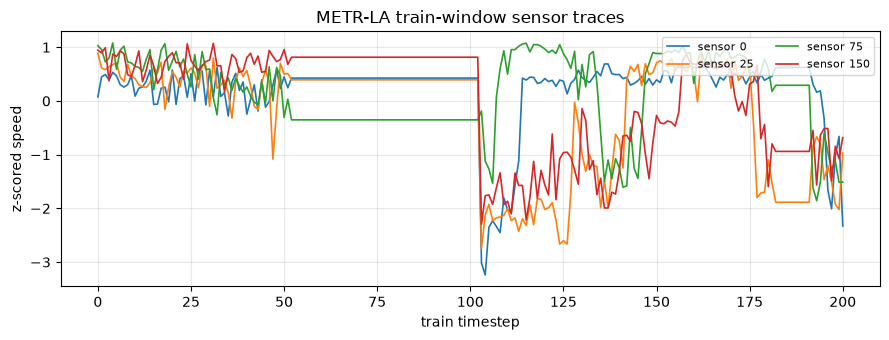

In [3]:
sensor_ids = [0, 25, 75, 150]
times = range(train_seq.num_timesteps)
fig, ax = plt.subplots(figsize=(9, 3.5))
for sid in sensor_ids:
    series = [float(train_seq[t].x[sid, 0]) for t in times]
    ax.plot(times, series, label=f"sensor {sid}", linewidth=1.2)
ax.set_xlabel("train timestep")
ax.set_ylabel("z-scored speed")
ax.set_title("METR-LA train-window sensor traces")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Train

Fit GraphKoopman (ODO + rollout ramp + early stopping) and the GNN teaching baselines.


In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# time_step is recorded for spectrum/API consistency; inert for this discrete-time fit.
koopman = GraphKoopmanModel(
    encoder=GNNEncoder(1, GK_HIDDEN, GK_LATENT),
    decoder=GNNDecoder(GK_LATENT, GK_HIDDEN, 1),
    latent_dim=GK_LATENT,
    time_step=5.0,
    koopman_parameterization="odo",
    koopman_max_spectral_radius=1.05,
)

loss_schedule = linear_ramp_loss_weights(
    constant_loss_weights(
        reconstruction=1.0, forward=1.0, rollout=0.25, eigenvalue=0.05
    ),
    constant_loss_weights(
        reconstruction=1.0, forward=0.5, rollout=2.0, eigenvalue=0.05
    ),
    ramp_epochs=RAMP_EPOCHS,
)

print(f"Fitting GraphKoopman ({EPOCHS} epochs max, early stopping)...")
history = koopman.fit(
    train_seq,
    validation_sequence=val_seq,
    epochs=EPOCHS,
    lr=LR_GK,
    loss_weight_schedule=loss_schedule,
    rollout_horizon=rollout_horizon,
    max_grad_norm=1.0,
    early_stopping_patience=30 if not IS_TEST else 5,
    restore_best_weights=True,
)
print(f"  done ({len(history.loss)} epochs tracked)")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Fitting STGCN ({GNN_EPOCHS} epochs)...")
stgcn = STGCNBaseline(
    1,
    GNN_HIDDEN,
    1,
    num_st_blocks=1 if IS_TEST else 2,
    history_len=2 if IS_TEST else 3,
).fit(train_seq, epochs=GNN_EPOCHS, lr=LR_GNN)
print("  done")

print(f"Fitting DCRNN ({GNN_EPOCHS} epochs)...")
dcrnn = DCRNNBaseline(
    1,
    GNN_HIDDEN,
    1,
    diffusion_steps=1 if IS_TEST else 2,
    history_len=1,
).fit(train_seq, epochs=GNN_EPOCHS, lr=LR_GNN)
print("  done")

print(
    f"Fitting GraphWaveNet ({GNN_EPOCHS} epochs"
    f"{', adaptive adj' if not IS_TEST else ''})..."
)
wavenet = GraphWaveNetBaseline(
    1,
    GNN_HIDDEN,
    1,
    num_layers=2 if IS_TEST else 4,
    history_len=2 if IS_TEST else 4,
    adaptive_adj=not IS_TEST,
).fit(train_seq, epochs=GNN_EPOCHS, lr=LR_GNN)
print("  done")

candidates = {
    "GraphKoopman": koopman,
    "STGCN": stgcn,
    "DCRNN": dcrnn,
    "GraphWaveNet": wavenet,
}

print(
    f"GraphKoopman final train loss={history.loss[-1]:.4f}; "
    f"best epoch tracked via early stopping / restore_best_weights"
)
print("Parameter counts:")
for name, model in candidates.items():
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  {name:>12}: {n_params:,}")
print("fitted:", ", ".join(candidates))


Fitting GraphKoopman (120 epochs max, early stopping)...


  done (38 epochs tracked)
Fitting STGCN (40 epochs)...
  done
Fitting DCRNN (40 epochs)...
  done
Fitting GraphWaveNet (40 epochs, adaptive adj)...
  done
GraphKoopman final train loss=1.1369; best epoch tracked via early stopping / restore_best_weights
Parameter counts:
  GraphKoopman: 16,769
         STGCN: 21,089
         DCRNN: 31,905
  GraphWaveNet: 47,681
fitted: GraphKoopman, STGCN, DCRNN, GraphWaveNet


## Evaluate on the held-out test split

Aggregate and per-horizon RMSE under the shared protocol.


In [5]:
rows = []
for name, model in candidates.items():
    result = evaluate_forecast(model, test_seq, horizons=HORIZONS)
    row = {"model": name, "aggregate": result.aggregate_rmse}
    for metric in result.horizons:
        row[f"h{metric.horizon}"] = metric.rmse
    rows.append(row)

header = ["model", *[f"h{h}" for h in HORIZONS], "aggregate"]
print("Multi-horizon test RMSE (z-scored speed; lower is better)")
print("  ".join(f"{col:>14}" for col in header))
for row in rows:
    cells_out = []
    for col in header:
        if col == "model":
            cells_out.append(f"{row['model']:>14}")
        else:
            cells_out.append(f"{row[col]:14.4f}")
    print("  ".join(cells_out))

ranked = sorted(rows, key=lambda r: r["aggregate"])
print(
    "Aggregate ranking (best → worst): "
    + " < ".join(r["model"] for r in ranked)
)


Multi-horizon test RMSE (z-scored speed; lower is better)
         model              h3              h6             h12       aggregate
  GraphKoopman          0.6515          0.6780          0.6824          0.6707
         STGCN          0.5726          0.6696          0.8807          0.7076
         DCRNN          0.7545          1.0566          1.4150          1.0754
  GraphWaveNet          0.6427          0.8748          1.1935          0.9036
Aggregate ranking (best → worst): GraphKoopman < STGCN < GraphWaveNet < DCRNN


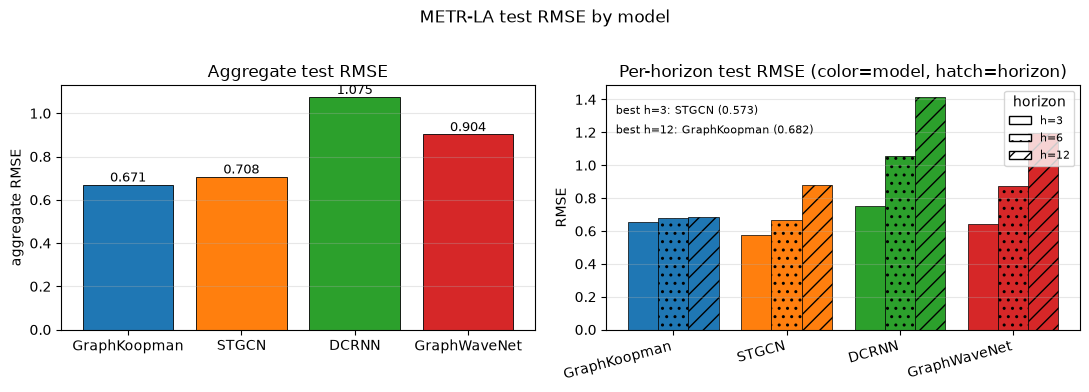

In [6]:
names = [row["model"] for row in rows]
aggregates = [row["aggregate"] for row in rows]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
hatches = ["", "..", "//", "xx"]
x = np.arange(len(names))
width = 0.8 / len(HORIZONS)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

bars = axes[0].bar(
    names, aggregates, color=colors[: len(names)], edgecolor="black", linewidth=0.6
)
axes[0].set_ylabel("aggregate RMSE")
axes[0].set_title("Aggregate test RMSE")
axes[0].grid(True, axis="y", alpha=0.3)
for bar, value in zip(bars, aggregates, strict=True):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

for i, h in enumerate(HORIZONS):
    values = [row[f"h{h}"] for row in rows]
    offset = (i - (len(HORIZONS) - 1) / 2) * width
    axes[1].bar(
        x + offset,
        values,
        width=width,
        color=colors[: len(names)],
        hatch=hatches[i % len(hatches)],
        edgecolor="black",
        linewidth=0.5,
    )
# Neutral proxy patches: hatch encodes horizon; bar fill still encodes model.
horizon_handles = [
    Patch(
        facecolor="white",
        edgecolor="black",
        hatch=hatches[i % len(hatches)],
        label=f"h={h}",
    )
    for i, h in enumerate(HORIZONS)
]
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=15, ha="right")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Per-horizon test RMSE (color=model, hatch=horizon)")
axes[1].legend(handles=horizon_handles, fontsize=8, title="horizon")
axes[1].grid(True, axis="y", alpha=0.3)

# Call out best model at the shortest and longest reported horizons.
for h, ypos in ((HORIZONS[0], 0.92), (HORIZONS[-1], 0.84)):
    best = min(rows, key=lambda r: r[f"h{h}"])
    axes[1].text(
        0.02,
        ypos,
        f"best h={h}: {best['model']} ({best[f'h{h}']:.3f})",
        transform=axes[1].transAxes,
        fontsize=8,
        va="top",
    )

fig.suptitle("METR-LA test RMSE by model", y=1.02)
plt.tight_layout()
plt.show()


## Interpret the results

Read the table and plots together with the protocol caveats:

- **Short vs long horizon.** On this run STGCN is strongest at the shortest
  horizon, while GraphKoopman wins at the longest horizon and on aggregate.
  That pattern fits a rollout-trained linear latent model: competitive when
  error compounds over many steps, not automatically best at one-step skill.
- **Unequal budgets.** GraphKoopman trains with ODO + rollout ramp + validation
  early stopping (`EPOCHS`); GNN refs use a shorter interactive budget
  (`GNN_EPOCHS`) and a shared teaching width. Parameter counts are printed
  above — capacity is **not** equalized, so treat the ranking as a teaching
  comparison, not a capacity-matched bake-off.
- **When to prefer GraphKoopman.** Choose it when you want multi-horizon
  forecast skill **plus** an inspectable linear latent operator/spectrum.
  Prefer a pure GNN baseline when you only need short-horizon point forecasts
  and do not care about a linear \(K\).


## Takeaways

- **Goal revisited:** a rollout-trained `GraphKoopmanModel` can compete with
  STGCN / DCRNN / Graph WaveNet teaching baselines under shared METR-LA
  evaluation — the missing nonlinear-GNN side of KoopmanGraph's motivation.
- **This run:** GraphKoopman leads on aggregate RMSE and at the longest horizon;
  STGCN wins the shortest horizon. Prefer GraphKoopman when you want competitive
  multi-horizon forecasts **plus** an inspectable linear latent operator/spectrum.
- **Protocol:** same chronological split and horizons; GraphKoopman uses
  ODO + rollout ramp + early stopping (`EPOCHS`); GNN refs use a shorter
  interactive budget (`GNN_EPOCHS`) and shared teaching width (capacity not
  equalized — see parameter counts).
- **API:** `from koopman_graph.baselines.gnn import STGCNBaseline, DCRNNBaseline,
  GraphWaveNetBaseline`.
- **Honesty:** GNN numbers are teaching baselines, not published SOTA
  reproductions; spectral tools remain Koopman/DMD-family.
- **Next steps:** compare against notebook 03's DMD/EDMD rows; try notebook 24's
  chaotic benchmarks if you want a nonlinearity stress test instead of traffic.

## Next steps

- See [`03_traffic_network.ipynb`](03_traffic_network.ipynb) for DMD/EDMD rows on METR-LA.
- See [`24_nonlinear_chaotic_benchmarks.ipynb`](24_nonlinear_chaotic_benchmarks.ipynb) for nonlinearity stress tests.
- See [`07_koopman_spectrum.ipynb`](07_koopman_spectrum.ipynb) to inspect the learned operator spectrum.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html).
